## Build dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float),
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n)
)
df['result'] = (score > score.median()).astype(int)

X = df.drop('result', axis=1)
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train SVM Classifier

In [2]:
# SVM is very sensitive to feature scale
# ALWAYS scale before SVM
pipeline_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(
        kernel       = 'rbf',
        # ↑ kernel type: 'linear', 'poly', 'rbf', 'sigmoid'
        #   rbf is best default — handles non-linear boundaries

        C            = 1.0,
        # ↑ penalty for misclassification
        #   large C  → narrow margin, fewer errors allowed
        #   small C  → wide margin, more errors allowed

        gamma        = 'scale',
        # ↑ influence radius for rbf kernel
        #   'scale' = 1/(n_features × X.var()) ← good default
        #   'auto'  = 1/n_features
        #   float   = manual value

        probability  = True,
        # ↑ enable predict_proba()
        #   disabled by default (slower to train)
        #   enable when you need probability estimates

        random_state = 42
    ))
])

pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

        Fail       0.90      0.88      0.89       102
        Pass       0.88      0.90      0.89        98

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



## Compare Kernels

Kernel: linear    CV Accuracy: 0.880 ± 0.004
Kernel: poly      CV Accuracy: 0.873 ± 0.010
Kernel: rbf       CV Accuracy: 0.878 ± 0.012
Kernel: sigmoid   CV Accuracy: 0.862 ± 0.020


C:\Users\muham\AppData\Local\Temp\ipykernel_10572\3153342280.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


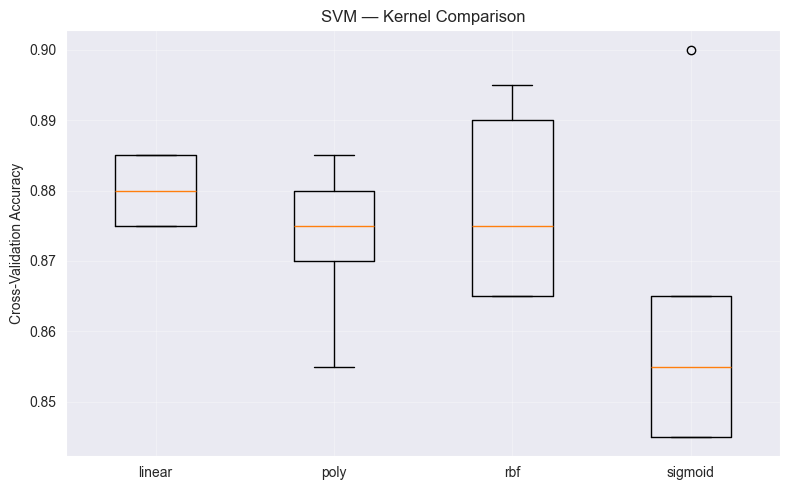

In [3]:
kernels    = ['linear', 'poly', 'rbf', 'sigmoid']
cv_results = {}

for kernel in kernels:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc',    SVC(kernel=kernel, random_state=42))
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_results[kernel] = scores
    print(f"Kernel: {kernel:8s}  "
          f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel("Cross-Validation Accuracy")
plt.title("SVM — Kernel Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize Decision Boundary (2D)

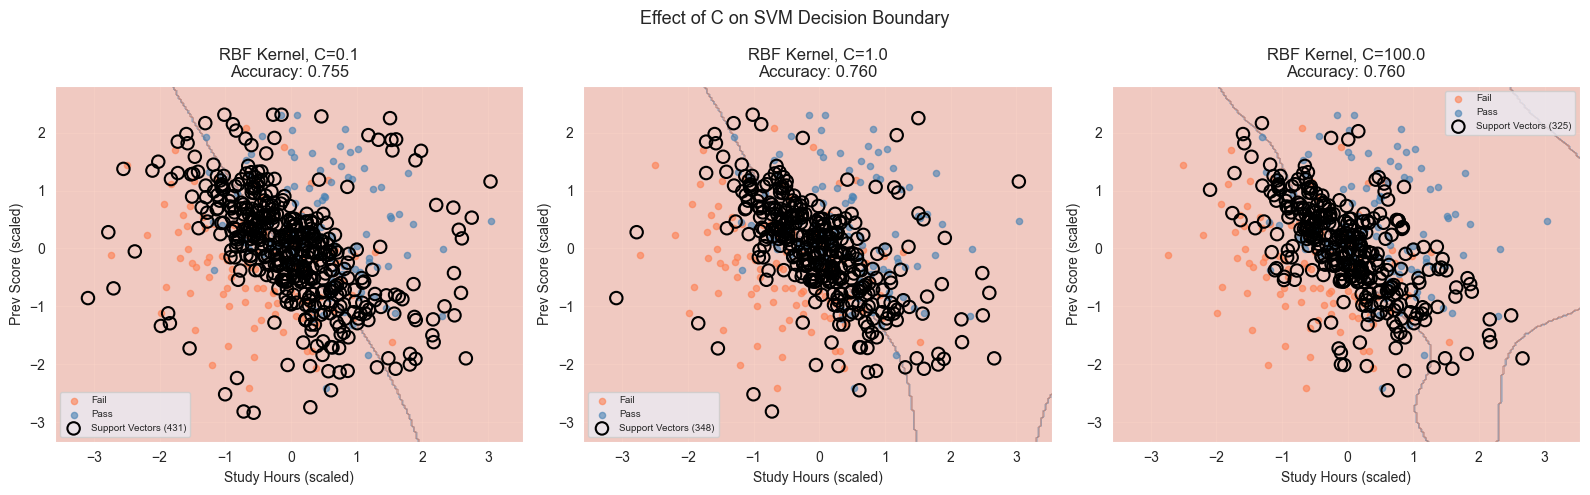

In [4]:
# Use only 2 features for visualization
X_2d = df[['study_hours', 'prev_score']].values
y_2d = df['result'].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
C_values   = [0.1, 1.0, 100.0]

for ax, C in zip(axes, C_values):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc',    SVC(kernel='rbf', C=C, gamma='scale'))
    ])
    pipe.fit(X_train_2d, y_train_2d)

    # Create mesh grid
    scaler_2d  = pipe.named_steps['scaler']
    svc_model  = pipe.named_steps['svc']

    X_scaled_2d = scaler_2d.transform(X_2d)
    x_min, x_max = X_scaled_2d[:, 0].min()-0.5, X_scaled_2d[:, 0].max()+0.5
    y_min, y_max = X_scaled_2d[:, 1].min()-0.5, X_scaled_2d[:, 1].max()+0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = svc_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3,
                colors=['coral', 'steelblue'])

    X_test_scaled = scaler_2d.transform(X_test_2d)
    ax.scatter(X_test_scaled[y_test_2d==0, 0],
               X_test_scaled[y_test_2d==0, 1],
               c='coral', s=20, alpha=0.6, label='Fail')
    ax.scatter(X_test_scaled[y_test_2d==1, 0],
               X_test_scaled[y_test_2d==1, 1],
               c='steelblue', s=20, alpha=0.6, label='Pass')

    # Highlight support vectors
    sv = svc_model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1],
               s=80, facecolors='none',
               edgecolors='black', linewidths=1.5,
               label=f'Support Vectors ({len(sv)})')

    acc = accuracy_score(y_test_2d, pipe.predict(X_test_2d))
    ax.set_title(f"RBF Kernel, C={C}\nAccuracy: {acc:.3f}")
    ax.set_xlabel("Study Hours (scaled)")
    ax.set_ylabel("Prev Score (scaled)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Effect of C on SVM Decision Boundary", fontsize=13)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [5]:
param_grid = {
    'svc__C'     : [0.1, 1.0, 10.0, 100.0],
    'svc__gamma' : ['scale', 'auto', 0.01, 0.1],
    'svc__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('svc', SVC())]),
    param_grid,
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:  ", grid_search.best_score_)
print("Test Accuracy:  ",
      accuracy_score(y_test, grid_search.predict(X_test)))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'svc__C': 0.1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV Score:   0.885
Test Accuracy:   0.89


# SVR

In [7]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Regression target — predict actual score
df['actual_score'] = score   # continuous target

X_reg = df.drop(['result', 'actual_score'], axis=1)
y_reg = df['actual_score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(
        kernel   = 'rbf',
        # ↑ same kernels as SVC

        C        = 1.0,
        # ↑ penalty for points outside the tube
        #   large C → penalize outliers more → tighter fit

        epsilon  = 0.1,
        # ↑ width of the insensitive tube
        #   points within epsilon → zero loss
        #   large epsilon → more tolerance → simpler model

        gamma    = 'scale'
    ))
])

pipeline_svr.fit(X_train_r, y_train_r)
y_pred_r = pipeline_svr.predict(X_test_r)

print("R² Score:", round(r2_score(y_test_r, y_pred_r), 4))
print("RMSE    :", mean_squared_error(y_test_r, y_pred_r)**0.5)

R² Score: 0.7052
RMSE    : 6.830679591391422


## Visualize SVR Tube

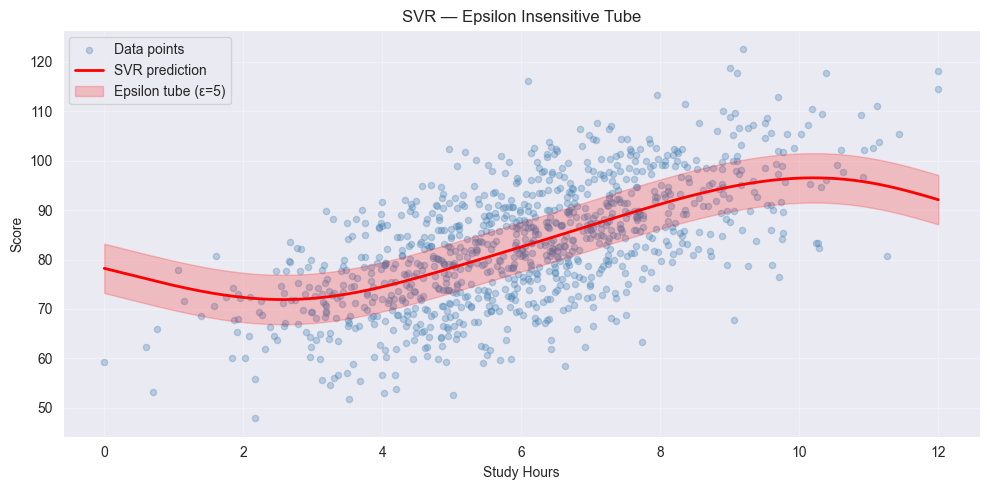

In [8]:
# Use 1 feature for clear visualization
X_1d       = df[['study_hours']].values
y_1d       = df['actual_score'].values
sort_idx   = X_1d[:, 0].argsort()
X_1d_sort  = X_1d[sort_idx]
y_1d_sort  = y_1d[sort_idx]

pipe_1d = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', C=1.0, epsilon=5.0, gamma='scale'))
])
pipe_1d.fit(X_1d, y_1d)

X_line       = np.linspace(X_1d.min(), X_1d.max(), 300).reshape(-1, 1)
y_pred_line  = pipe_1d.predict(X_line)

plt.figure(figsize=(10, 5))
plt.scatter(X_1d, y_1d, color='steelblue', alpha=0.3,
            s=20, label='Data points')
plt.plot(X_line, y_pred_line,
         color='red', linewidth=2, label='SVR prediction')
plt.fill_between(X_line.ravel(),
                 y_pred_line - 5,
                 y_pred_line + 5,
                 alpha=0.2, color='red', label='Epsilon tube (ε=5)')
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("SVR — Epsilon Insensitive Tube")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()